In [9]:
import os
import matplotlib.pyplot as plt
import pandas as pd


In [10]:
STAT_PATH = "C:/Users/xmelo/AppData/LocalLow/DefaultCompany/_monobeh_boinc"
TASK_DYNAMIC_NAME = "task_dynamic"
EXP_NAME = "statistics"


In [11]:
def load_valid_series(file_path):
    raw = pd.read_csv(file_path, sep=r"\s+", header=None)
    if raw.shape[1] == 1:
        df = raw.rename(columns={0: "valid_delta"})
        df["second"] = df.index
    else:
        df = raw.iloc[:, :2].copy()
        df.columns = ["application", "valid_delta"]
        df["application"] = df["application"].astype(int)
        df["second"] = df.groupby("application").cumcount()
        df = df.groupby("second", as_index=False)["valid_delta"].sum()
    df["valid_workunits"] = df["valid_delta"].cumsum()
    df["time_hours"] = df["second"] / 3600.0
    return df

def plot_valid_workunits(ax, file_path, label):
    df = load_valid_series(file_path)
    ax.plot(df["time_hours"], df["valid_workunits"], label=label)
    ax.set_title("Workunits that reached quorum")
    ax.set_xlabel("Time, hours")
    ax.set_ylabel("Validated workunits, units")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)


found ['statistics_1', 'statistics_2']


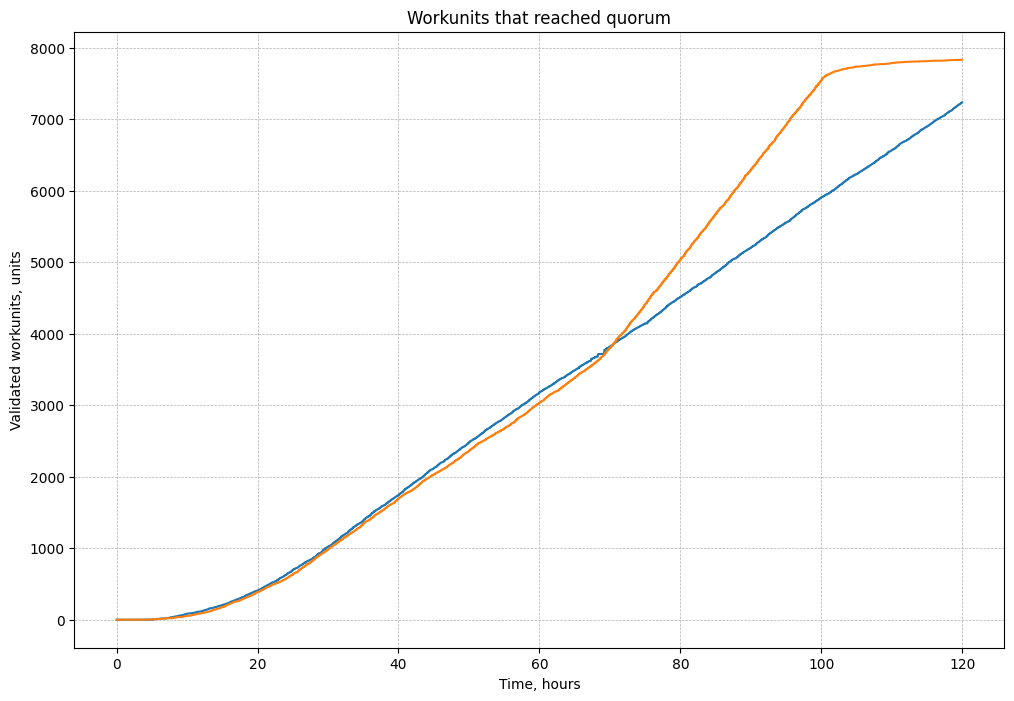

In [12]:
folders = sorted(
    f
    for f in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, f)) and f.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

fig, ax = plt.subplots(figsize=(12, 8))

for folder in folders:
    full_path = os.path.join(STAT_PATH, folder)
    task_dynamic_path = os.path.join(full_path, TASK_DYNAMIC_NAME)
    if not os.path.exists(task_dynamic_path):
        print(f"skip {folder}: {TASK_DYNAMIC_NAME} not found")
        continue
    plot_valid_workunits(ax, task_dynamic_path, folder)

#ax.legend()
plt.show()
